<a href="https://www.kaggle.com/code/hammadrehmani/youtube-video-view-prediction-eda-ml?scriptVersionId=321306113" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
pip install isodate

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
import isodate

#  Show Whole Numbers Without Decimals

In [3]:
pd.set_option('display.float_format', '{:,.0f}'.format)

# Load the Dataset

In [4]:
data = pd.read_csv('/kaggle/input/youtube-data-for-analytics-600-rows/youtube_data.csv')

In [5]:
df = data.copy()

In [6]:
df.head()

,video_id,title,description,published_date,channel_id,channel_title,tags,category_id,view_count,like_count,comment_count,duration,thumbnail
0,gsJAlLOFBv0,TINY Tech That Actually Works,No description available,2025-05-02T17:37:10Z,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,"['tiny', 'tech', 'gadgets', 'small', 'miniature']",28,"8,962,092","243,350",515,PT57S,https://i.ytimg.com/vi/gsJAlLOFBv0/default.jpg
1,ypicIkaiViM,AI & future of workforce: Andrew Yang on how t...,"Andrew Yang, Forward Party co-chair and former...",2025-06-18T12:39:53Z,UCrp_UI8XtuYfpiqluWLD7Lw,CNBC Television,"['Squawk Box U.S.', 'CNBC', 'business news', '...",25,"289,626","3,393","1,240",PT7M50S,https://i.ytimg.com/vi/ypicIkaiViM/default.jpg
2,1Nef8LPO-jo,5 ILLEGAL gadgets that will get you ARRESTED,#shorts #technology \n\nI spend a LOT of time ...,2022-11-01T11:00:06Z,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,"['shorts', 'tech']",28,"81,372,201","4,178,447","6,378",PT47S,https://i.ytimg.com/vi/1Nef8LPO-jo/default.jpg
3,lCHqmzynO-s,Overrated vs. Underrated Tech,💬 Join my Discord server: https://discord.gg/g...,2024-07-08T18:04:31Z,UCPk2s5c4R_d-EUUNvFFODoA,Gohar Khan,"['thailand', 'surin', 'style', 'travel', 'day'...",27,"21,255,964","909,386","2,681",PT31S,https://i.ytimg.com/vi/lCHqmzynO-s/default.jpg
4,7uFrtqSwYzM,APPLE Glass Revolutionizes AR Experience Forever!,Discover the revolutionary world of augmented ...,2024-12-22T16:49:00Z,UCxqG_E-68WAE0TWYfIopv6Q,Digifix,"['apple glasses price', 'apple glasses design'...",28,"2,790,436","44,278","1,359",PT16S,https://i.ytimg.com/vi/7uFrtqSwYzM/default.jpg


In [7]:
print(f"The number of Rows in a dataset is {df.shape[0]}")
print(f"The number of columns in a dataset is {df.shape[1]}")

The number of Rows in a dataset is 600
The number of columns in a dataset is 13


# Data Cleaning & Feature Engineering

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        600 non-null    object 
 1   title           600 non-null    object 
 2   description     600 non-null    object 
 3   published_date  600 non-null    object 
 4   channel_id      600 non-null    object 
 5   channel_title   600 non-null    object 
 6   tags            600 non-null    object 
 7   category_id     600 non-null    int64  
 8   view_count      600 non-null    float64
 9   like_count      600 non-null    float64
 10  comment_count   600 non-null    float64
 11  duration        600 non-null    object 
 12  thumbnail       600 non-null    object 
dtypes: float64(3), int64(1), object(9)
memory usage: 61.1+ KB


In [9]:
df.duplicated().sum()

16

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

0

In [12]:
df['published_date'] = pd.to_datetime(df['published_date'], format='ISO8601')

In [13]:
df['hour'] = df['published_date'].dt.hour

In [14]:
df['duration_seconds'] = df['duration'].apply(lambda x: isodate.parse_duration(x).total_seconds())

In [15]:
df['tag'] = df['tags'].apply(lambda x: x.replace("'",''))
df['tag'] = df['tag'].apply(lambda x: x.replace('[',''))
df['tag'] = df['tag'].apply(lambda x: x.replace(']',''))

In [16]:
tags ={
    
}
for i in df['tag']:
    for j in i.split(','):
       tag = j.lower().strip()
       if tag in tags: 
           tags[tag] = tags[tag]+1
       else:
           tags[tag] = 1

In [17]:
tags_df = pd.DataFrame.from_dict(tags,orient='index',columns=['count'])
tags_df2 = tags_df.reset_index().rename(columns={'index': 'tag'})

In [18]:
tags_df3 = tags_df2.sort_values('count',ascending=False).head(30)

In [19]:
tags_df3

,tag,count
27,travel,491
29,asia,490
34,animal,246
30,elephant,245
31,bangkok,245
32,elephantnature,245
33,asian,245
35,wildlife,245
36,chiang,245
37,african,245


# Exploratory Data Analysis

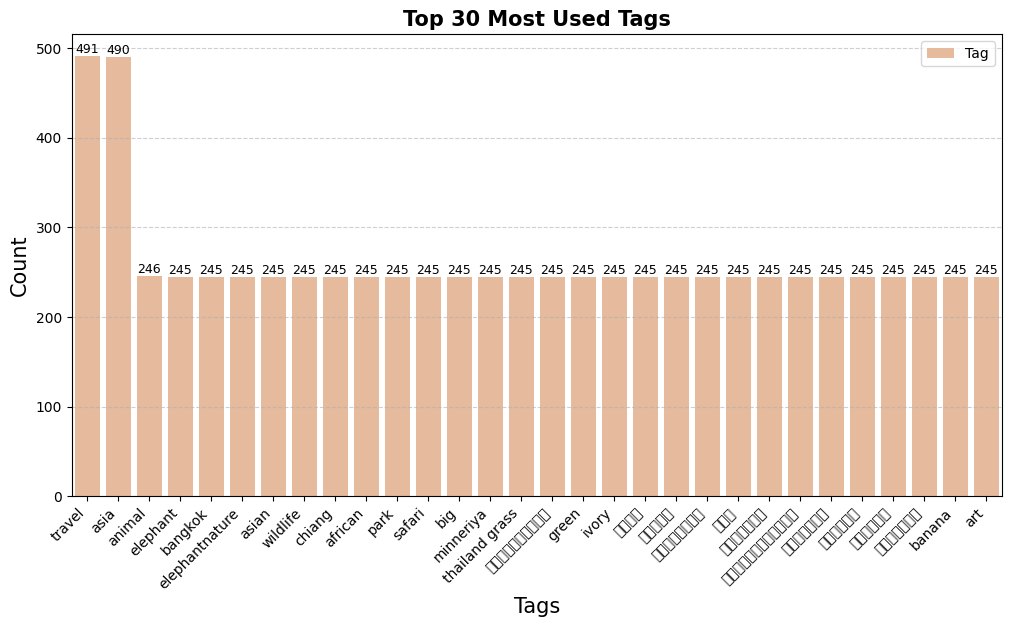

In [20]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='tag', y = 'count',data=tags_df3,label='Tag',color='#f1b791')
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')
ax.bar_label(ax.containers[0],fontsize=9)
plt.title('Top 30 Most Used Tags',fontweight='bold',fontsize=15)
plt.xlabel('Tags',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.legend()
plt.show()

In [21]:
df.columns

Index(['video_id', 'title', 'description', 'published_date', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'comment_count', 'duration', 'thumbnail', 'hour', 'duration_seconds',
       'tag'],
      dtype='object')

In [22]:
category_id_view = df.groupby(['category_id'])['view_count'].mean()
category_id_like = df.groupby(['category_id'])['like_count'].mean()
category_id_comment = df.groupby(['category_id'])['comment_count'].mean()

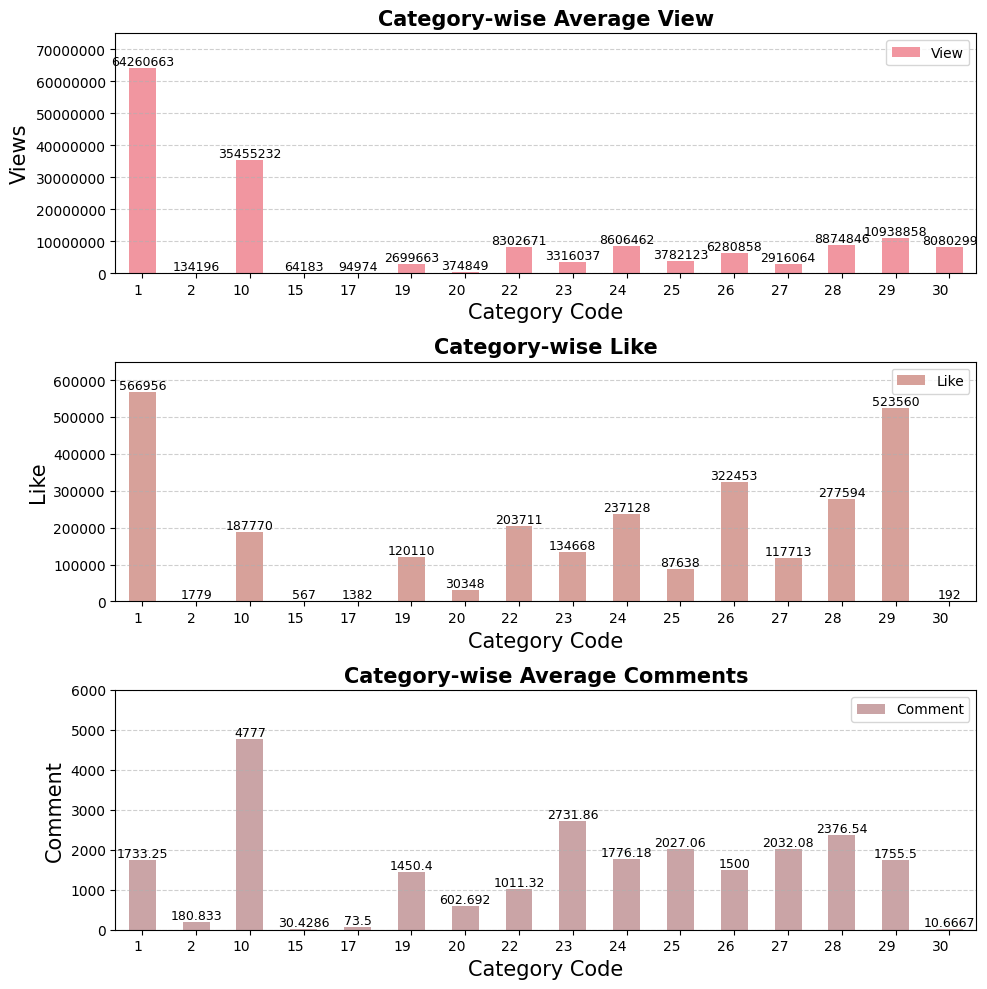

In [23]:
plt.figure(figsize=(10, 10))


plt.subplot(3, 1, 1)
ax = category_id_view.plot(kind='bar',color='#f196a0',label='View')
ax.set_xticklabels(ax.get_xticklabels(),rotation=0,ha='right')
plt.ticklabel_format(style='plain', axis='y')
ax.bar_label(ax.containers[0],fontsize=9,fmt='%.0f')
plt.title('Category-wise Average View', fontweight='bold', fontsize=15)
plt.xlabel('Category Code',fontsize=15)
plt.ylabel('Views',fontsize=15)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.ylim(0,75000000)
plt.legend()



plt.subplot(3, 1, 2)
ax = category_id_like.plot(kind='bar',color='#d7a19a',label='Like')
ax.set_xticklabels(ax.get_xticklabels(),rotation=0,ha='right')
plt.ticklabel_format(style='plain', axis='y')
ax.bar_label(ax.containers[0],fontsize=9,fmt='%.0f')
plt.title('Category-wise Like', fontweight='bold', fontsize=15)
plt.xlabel('Category Code',fontsize=15)
plt.ylabel('Like',fontsize=15)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.ylim(0,650000)
plt.legend()



plt.subplot(3, 1, 3)
ax = category_id_comment.plot(kind='bar',color='#caa4a6',label='Comment')
ax.set_xticklabels(ax.get_xticklabels(),rotation=0,ha='right')
ax.bar_label(ax.containers[0],fontsize=9)
plt.title('Category-wise Average Comments', fontweight='bold', fontsize=15)
plt.xlabel('Category Code',fontsize=15)
plt.ylabel('Comment',fontsize=15)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.ylim(0,6000)
plt.legend()

plt.tight_layout()
plt.show()

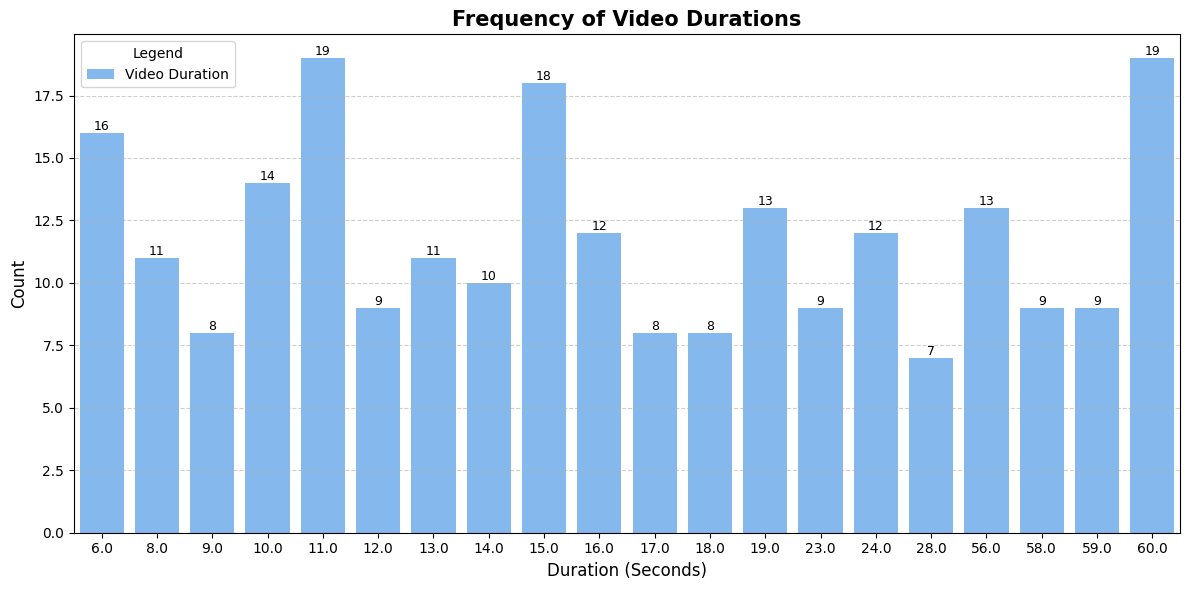

In [24]:
duration_counts = df['duration_seconds'].value_counts().head(20)


plt.figure(figsize=(12, 6))
ax = sns.barplot(x=duration_counts.index, y=duration_counts.values, color='#74b9ff', label='Video Duration')
ax.set_xticklabels(ax.get_xticklabels(),rotation=0,ha='center')
ax.bar_label(ax.containers[0],fontsize=9)
plt.title('Frequency of Video Durations', fontsize=15, fontweight='bold')
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Legend')
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

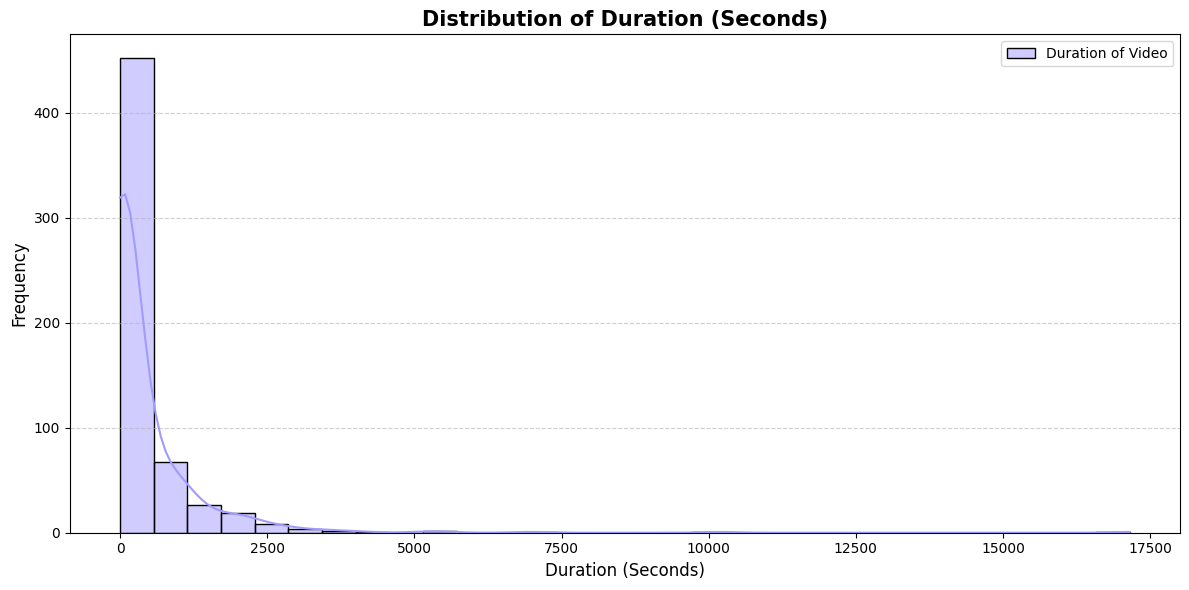

In [25]:
plt.figure(figsize=(12, 6))
sns.histplot(df['duration_seconds'], bins=30, kde=True, color='#a29bfe',label='Duration of Video')
plt.title('Distribution of Duration (Seconds)', fontsize=15, fontweight='bold')
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

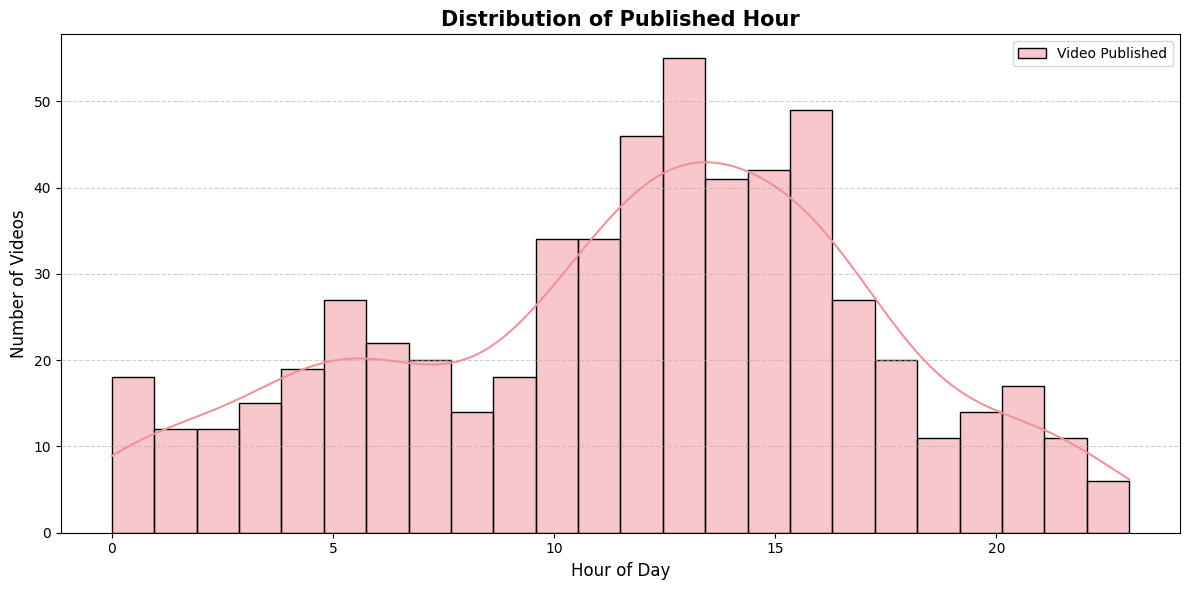

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(df['hour'], bins=24, kde=True, color='#f1919b',label='Video Published')
plt.title('Distribution of Published Hour', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Videos', fontsize=12)
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

# Dealing with Outliers

In [27]:
df.describe()

,category_id,view_count,like_count,comment_count,hour,duration_seconds
count,584,584,584,584,584,584
mean,25,"8,234,730","220,485","1,967",12,421
std,5,"24,855,934","513,563","4,402",6,"1,107"
min,1,312,0,0,0,0
25%,22,"92,252","1,646",15,8,18
50%,27,"990,998","22,149",264,13,46
75%,28,"6,239,264","217,465","1,819",16,441
max,30,"343,758,991","4,421,091","40,241",23,"17,150"


In [28]:
df.columns

Index(['video_id', 'title', 'description', 'published_date', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'comment_count', 'duration', 'thumbnail', 'hour', 'duration_seconds',
       'tag'],
      dtype='object')

In [29]:
targ_columns = ['view_count', 'like_count', 'comment_count']
# for i in range(0,len(targ_columns)):

fig=px.box(data_frame=df,x='view_count')
fig.show(renderer='iframe_connected')



fig=px.box(data_frame=df,x='like_count')
fig.show()



fig=px.box(data_frame=df,x='comment_count')
fig.show()

In [30]:
New_df = df.copy()

for col in targ_columns:
    Q1 = New_df[col].quantile(0.25)
    Q3 = New_df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    New_df[col] = np.where(
        New_df[col] > upper_bound,  
        upper_bound,
        np.where(
            New_df[col] < lower_bound,
            lower_bound,
            New_df[col]  
        )
    )
    
df2 = New_df

In [31]:
for i in range(0,len(targ_columns)):
    fig=px.box(data_frame=df2,x=targ_columns[i])
    fig.show(renderer='iframe')

In [32]:
df2.shape

(584, 16)

In [33]:
df2.describe()

,category_id,view_count,like_count,comment_count,hour,duration_seconds
count,584,584,584,584,584,584
mean,25,"4,068,076","129,159","1,168",12,421
std,5,"5,542,396","179,648","1,619",6,"1,107"
min,1,312,0,0,0,0
25%,22,"92,252","1,646",15,8,18
50%,27,"990,998","22,149",264,13,46
75%,28,"6,239,264","217,465","1,819",16,441
max,30,"15,459,782","541,193","4,525",23,"17,150"


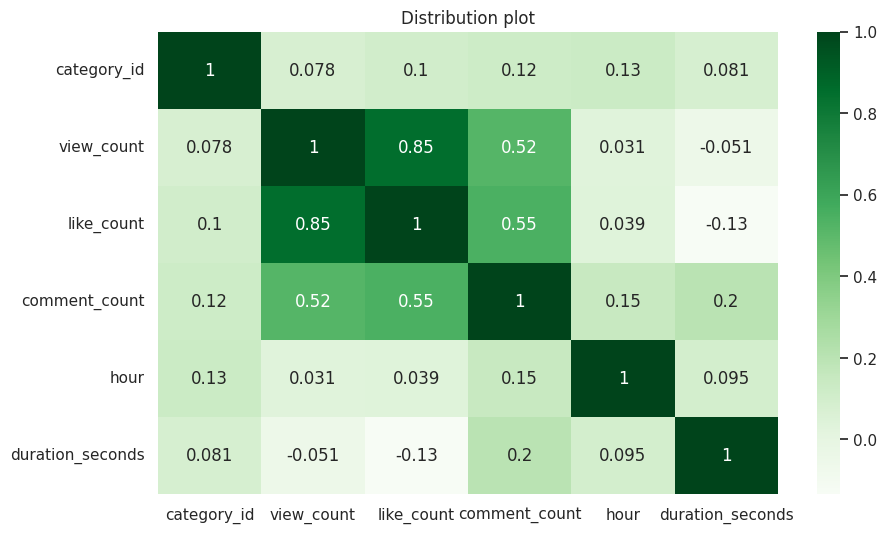

In [34]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap='Greens')
plt.title('Distribution plot')
plt.show()

# Machine Learning

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    StackingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [36]:
df2.columns

Index(['video_id', 'title', 'description', 'published_date', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'comment_count', 'duration', 'thumbnail', 'hour', 'duration_seconds',
       'tag'],
      dtype='object')

# Prepare Features and Target

In [37]:
X = df2[['like_count','comment_count','hour']]
y = df2['view_count']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Training Shape:', X_train.shape)
print('Testing Shape:', X_test.shape)

Training Shape: (467, 3)
Testing Shape: (117, 3)


# Feature Scaling

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Models

In [39]:
models = {
    'Linear Regression': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    
    'AdaBoost': AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),
    
    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    
    'LightGBM': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),
    
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),
    
    'SVR': SVR(
        kernel='rbf',
        C=100
    ),
    
    'KNN': KNeighborsRegressor(
        n_neighbors=5
    )
}

# Train and Evaluate Models

In [40]:
results = []

for name, model in models.items():
    
    print(f'\nTraining {name}...')
    
    # Use scaled data for SVR and KNN
    if name in ['SVR', 'KNN']:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append([
        name,
        mae,
        rmse,
        r2
    ])


Training Linear Regression...

Training Random Forest...

Training Extra Trees...

Training Gradient Boosting...

Training AdaBoost...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001877 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 322
[LightGBM] [Info] Number of data points in the train set: 467, number of used features: 3
[LightGBM] [Info] Start training from score 4023335.002141
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

# Model Comparison Table

In [41]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2 Score']
)

results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

results_df.style.background_gradient(cmap='Blues')

,Model,MAE,RMSE,R2 Score
7,CatBoost,1527788.858706,2721853.568512,0.755635
0,Linear Regression,1798639.546366,2766630.161212,0.747529
9,KNN,1580522.081696,2783828.049515,0.744380
4,AdaBoost,1841675.044569,2846991.568559,0.732649
2,Extra Trees,1630769.824216,2924500.663816,0.717893
1,Random Forest,1614859.649322,2974264.700758,0.708211
3,Gradient Boosting,1655262.994583,3128521.357825,0.677159
5,XGBoost,1846618.935016,3163777.153743,0.669842
6,LightGBM,1909696.734072,3331907.604018,0.633819
8,SVR,3968353.386782,6434468.761047,-0.365637


# Visualize Model Performance

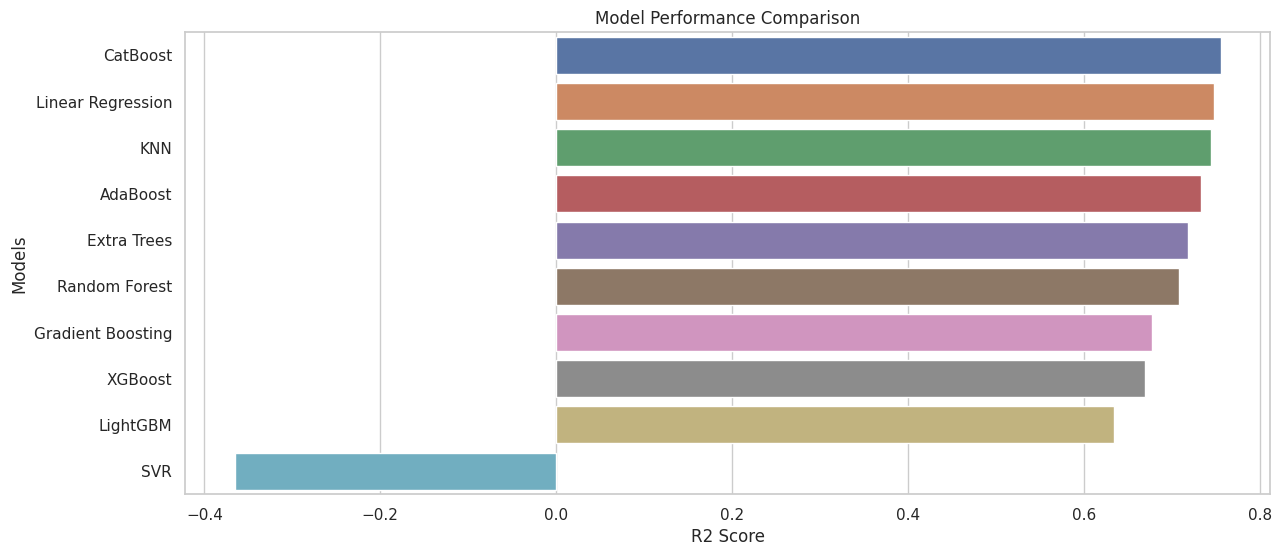

In [42]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=results_df,
    x='R2 Score',
    y='Model'
)

plt.title('Model Performance Comparison')
plt.xlabel('R2 Score')
plt.ylabel('Models')
plt.show()

# Cross Validation

In [43]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print('Cross Validation Scores:', cv_scores)
print('Average CV Score:', cv_scores.mean())

Cross Validation Scores: [0.63986659 0.72547893 0.68742911 0.70968852 0.65282753]
Average CV Score: 0.6830581344458743


# Hyperparameter Tuning

In [44]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print('Best Parameters:')
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01}


# Stacking Ensemble Model

In [45]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=300, random_state=42)),
    ('lgbm', LGBMRegressor(n_estimators=300, random_state=42))
]

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

stack_model.fit(X_train, y_train)

stack_predictions = stack_model.predict(X_test)

stack_r2 = r2_score(y_test, stack_predictions)

print('Stacking Model R2 Score:', stack_r2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 322
[LightGBM] [Info] Number of data points in the train set: 467, number of used features: 3
[LightGBM] [Info] Start training from score 4023335.002141
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

# Feature Importance

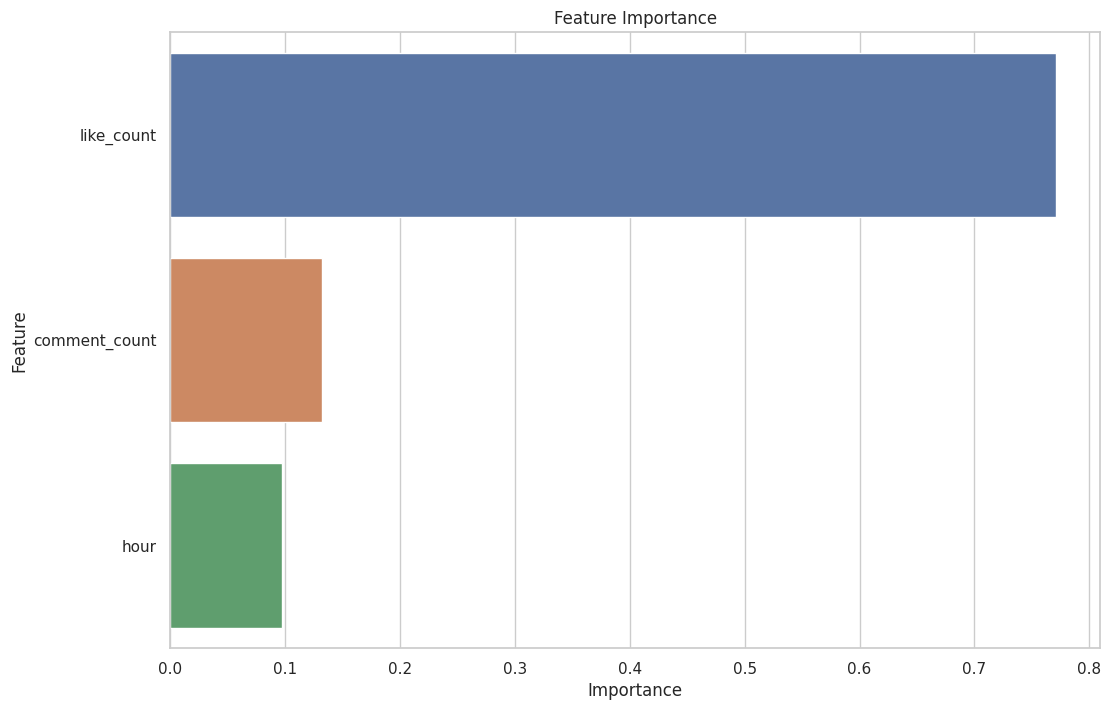

In [46]:
best_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

best_model.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

# Final Prediction Example

In [47]:
final_model = stack_model

predictions = final_model.predict(X_test)

prediction_df = pd.DataFrame({
    'Actual Views': y_test.values,
    'Predicted Views': predictions
})

prediction_df.head(10)

,Actual Views,Predicted Views
0,"1,176,050","1,026,478"
1,"29,593","228,754"
2,"1,709,718","1,723,240"
3,"1,081,527","2,391,810"
4,"5,331","171,431"
5,"4,006,570","3,427,598"
6,"15,459,782","14,525,030"
7,"43,508","5,964,955"
8,"492,744","1,456,733"
9,"440,548","418,009"
